# EDA по данным GitHub: пользователи и репозитории

В этом ноутбуке мы выполним EDA по двум выгрузкам с GitHub:
- users_filtered.csv - данные о пользователях
- repos_filtered.csv - данные о репозиториях

## 1. Импорт библиотек и загрузка данных


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import seaborn as sns

In [67]:
users = pd.read_csv("users_filtered.csv", index_col= 0)
repos = pd.read_csv("repos_filtered.csv", index_col=0)

## 2. Первичный осмотр данных

In [68]:
print("Размер датасета users:", users.shape)
print("Размер датасета с repos:", repos.shape)

Размер датасета users: (1000, 19)
Размер датасета с repos: (69941, 29)


In [69]:
users.head()

,login,id,type,html_url,site_admin,user_view_type,name,bio,location,company,blog,hireable,followers,following,public_repos,public_gists,created_at,updated_at,twitter_username
0,Kwynto,31433211,User,https://github.com/Kwynto,False,public,Constantine Zavezeon,"Programmers have existed in all ages, and were...",Russia,NaN,NaN,NaN,14247,7,20,2,2017-08-29T07:10:05Z,2026-03-01T17:53:12Z,NaN
1,K1rsN7,123446875,User,https://github.com/K1rsN7,False,public,Kirill Sukhorukov,‍💻 Data Scientist | 👨‍🎓 Student |\r\nI use @me...,"Russia, Nizhny Novgorod",Searching...,https://k1rsn7.github.io/,NaN,9303,9898,22,2,2023-01-24T07:44:21Z,2026-04-05T16:27:28Z,NaN
2,DIMFLIX,112165977,User,https://github.com/DIMFLIX,False,public,DIMFLIX,I use @meowrch btw,"Russia, Nizhny Novgorod",meowrch,https://dimflix.github.io/,NaN,9109,9615,19,0,2022-08-26T09:16:48Z,2026-03-17T11:34:57Z,NaN
3,ValdikSS,3054729,User,https://github.com/ValdikSS,False,public,ValdikSS,NaN,Russia,ProstoVPN.org,http://valdikss.org.ru,NaN,5167,0,69,24,2012-12-16T09:09:59Z,2026-03-07T22:56:11Z,NaN
4,nfterrax,97410466,User,https://github.com/nfterrax,False,public,NFTerraX,Crypto-Enthusiast | Web3 Community Manager | W...,Russia,NFTerraX,https://nfterrax.online,NaN,3484,6,4,0,2022-01-09T20:57:08Z,2026-03-09T11:51:10Z,nfterrax


In [70]:
repos.head()

,sample_user_login,id,name,full_name,html_url,description,fork,private,archived,disabled,...,open_issues_count,size,created_at,updated_at,pushed_at,default_branch,visibility,readme,lang_bytes,lang_pct
0,Kwynto,515339264,agonist,Kwynto/agonist,https://github.com/Kwynto/agonist,A program for checking and maintaining an awes...,False,False,False,False,...,0,125,2022-07-18T20:58:12Z,2026-04-01T19:12:49Z,2024-07-31T19:33:11Z,main,public,# AGonist\nA program for checking and maintain...,"{""Go"": 14480}","{""Go"": 100.0}"
1,Kwynto,471783700,awesome-go,Kwynto/awesome-go,https://github.com/Kwynto/awesome-go,"A curated list of awesome Go frameworks, libra...",True,False,False,False,...,0,10576,2022-03-19T18:43:37Z,2026-01-21T09:31:53Z,2025-11-30T04:48:42Z,main,public,"# Awesome Go\n\n<a href=""https://awesome-go.co...","{""Go"": 26344}","{""Go"": 100.0}"
2,Kwynto,672090323,base-folders-go,Kwynto/base-folders-go,https://github.com/Kwynto/base-folders-go,This is a simple repository with base folders ...,False,False,False,False,...,0,2,2023-07-28T22:47:06Z,2026-01-21T09:38:33Z,2024-07-31T19:31:56Z,main,public,# name repository \n\nThis is a simple reposit...,"{""Go"": 34}","{""Go"": 100.0}"
3,Kwynto,773330026,colorable,Kwynto/colorable,https://github.com/Kwynto/colorable,Colorable writer for windows.,False,False,False,False,...,0,9,2024-03-17T11:30:47Z,2026-01-21T09:44:26Z,2024-03-17T12:07:31Z,main,public,# colorable\n\nThis is a fork of the project g...,"{""Go"": 29231, ""Shell"": 273}","{""Go"": 99.0747017354, ""Shell"": 0.9252982646}"
4,Kwynto,674351858,exps-and-tests,Kwynto/exps-and-tests,https://github.com/Kwynto/exps-and-tests,This is an experimental repository,False,False,False,False,...,0,334,2023-08-03T18:27:13Z,2026-01-21T09:38:39Z,2024-01-04T08:21:43Z,main,public,# exps-and-tests\nThis is an experimental repo...,"{""Go"": 154687, ""CSS"": 49298, ""HTML"": 41696, ""P...","{""Go"": 62.4594201728, ""CSS"": 19.9055156263, ""H..."


In [71]:
users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   login             1000 non-null   object
 1   id                1000 non-null   int64 
 2   type              1000 non-null   object
 3   html_url          1000 non-null   object
 4   site_admin        1000 non-null   bool  
 5   user_view_type    1000 non-null   object
 6   name              949 non-null    object
 7   bio               547 non-null    object
 8   location          1000 non-null   object
 9   company           417 non-null    object
 10  blog              540 non-null    object
 11  hireable          310 non-null    object
 12  followers         1000 non-null   int64 
 13  following         1000 non-null   int64 
 14  public_repos      1000 non-null   int64 
 15  public_gists      1000 non-null   int64 
 16  created_at        1000 non-null   object
 17  updated_at        10

In [72]:
repos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69941 entries, 0 to 69940
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sample_user_login  69941 non-null  object
 1   id                 69941 non-null  int64 
 2   name               69940 non-null  object
 3   full_name          69941 non-null  object
 4   html_url           69941 non-null  object
 5   description        55098 non-null  object
 6   fork               69941 non-null  bool  
 7   private            69941 non-null  bool  
 8   archived           69941 non-null  bool  
 9   disabled           69941 non-null  bool  
 10  owner_login        69941 non-null  object
 11  owner_type         69941 non-null  object
 12  language           45588 non-null  object
 13  topics             69941 non-null  object
 14  license_spdx_id    37155 non-null  object
 15  license_name       37155 non-null  object
 16  stargazers_count   69941 non-null  int64 
 17

### Выводы

В выборке 1000 пользователей и 69941 репозиториев. В users наблюдений значительно меньше, чем в repos, что логично, тк одному пользователю может соответствовать несколько репозиториев




## 3. Проверка данных на пропуски и дубликаты

In [73]:
print("Полных дубликатов строк в users:", users.duplicated().sum())
print("Полных дубликатов строк в repos:", repos.duplicated().sum())

Полных дубликатов строк в users: 0
Полных дубликатов строк в repos: 0


In [74]:
def missing_values_table(df):

    mis_val = df.isnull().sum()

    mis_val_percent = 100 * mis_val / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table_ren_columns = mis_val_table.rename(columns={0: 'Пропущенные значения', 1: '% от всех значений'})

    mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:, 1] != 0].sort_values('% от всех значений', ascending=False).round(1)

    print("В выбранном датасете " + str(df.shape[1]) + " столбцов")
    print("В " + str(mis_val_table_ren_columns.shape[0]) + " столбцах есть пропущенные значения")

    return mis_val_table_ren_columns

In [75]:
missing_values_table(users)

В выбранном датасете 19 столбцов
В 6 столбцах есть пропущенные значения


,Пропущенные значения,% от всех значений
twitter_username,842,84.2
hireable,690,69.0
company,583,58.3
blog,460,46.0
bio,453,45.3
name,51,5.1


In [76]:
missing_values_table(repos)

В выбранном датасете 29 столбцов
В 9 столбцах есть пропущенные значения


,Пропущенные значения,% от всех значений
license_name,32786,46.9
license_spdx_id,32786,46.9
language,24353,34.8
description,14843,21.2
readme,10126,14.5
lang_pct,324,0.5
lang_bytes,324,0.5
pushed_at,3,0.0
name,1,0.0


### Выводы

Получаем, что полных дубликатов у нас в данных нет - это хорошо

Пропуски есть. Например, пользователи чаще всего не заполняют twitter_username, hireable, company - больше, чем у половины пользователей эти значения не заполнены. У репозиториев не всегда указаны license, основной язык в поле language или description

В целом с данными можно работать




## 4. Статистика по базовым числовым признакам

Посмотрим на базовые числовые признаки пользователей и репозиториев, выведем их статистику

In [77]:
users[["followers", "following", "public_repos", "public_gists"]].describe()

,followers,following,public_repos,public_gists
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,205.481000,106.194000,69.940000,12.36500
std,681.284891,549.596558,300.558833,34.97472
min,49.000000,0.000000,0.000000,0.00000
25%,63.000000,2.000000,17.000000,0.00000
50%,87.000000,17.000000,35.000000,1.00000
75%,155.000000,69.000000,69.250000,9.00000
max,14247.000000,9898.000000,7635.000000,450.00000


In [78]:
repos[["stargazers_count", "forks_count", "watchers_count", "open_issues_count", "size"]].describe()

,stargazers_count,forks_count,watchers_count,open_issues_count,size
count,69941.000000,69941.000000,69941.000000,69941.000000,6.994100e+04
mean,10.682690,2.426688,10.682690,0.793154,3.693435e+04
std,204.354692,60.713961,204.354692,14.496656,3.670609e+05
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000,6.000000e+01
50%,0.000000,0.000000,0.000000,0.000000,4.850000e+02
75%,1.000000,0.000000,1.000000,0.000000,6.080000e+03
max,28081.000000,12941.000000,28081.000000,2090.000000,4.568061e+07


Тут можно заметить, что значения в столбцах stargazers_count и watchers_count совпадают по всем параметрам. Проверим, есть ли вообще смысл рассматривать их по отдельности

In [79]:
print("Доля строк, где watchers_count совпадает со stargazers_count:", (repos["watchers_count"] == repos["stargazers_count"]).mean())

Доля строк, где watchers_count совпадает со stargazers_count: 1.0


Значит, во всех строках значения watchers_count и stargazers_count одинаковые, поэтому рассматривать их по отдельности нет смысла

### Выводы

По таблицам статистик можно заметить, что данные распределены неравномерно - почти всё сосредоточено на малых значениях, а большие значения встречаются редко. То есть почти все распределения скошены вправо





## 5. Univariate analysis для пользователей

Построим базовые гистограммы по основным числовым признакам пользователей


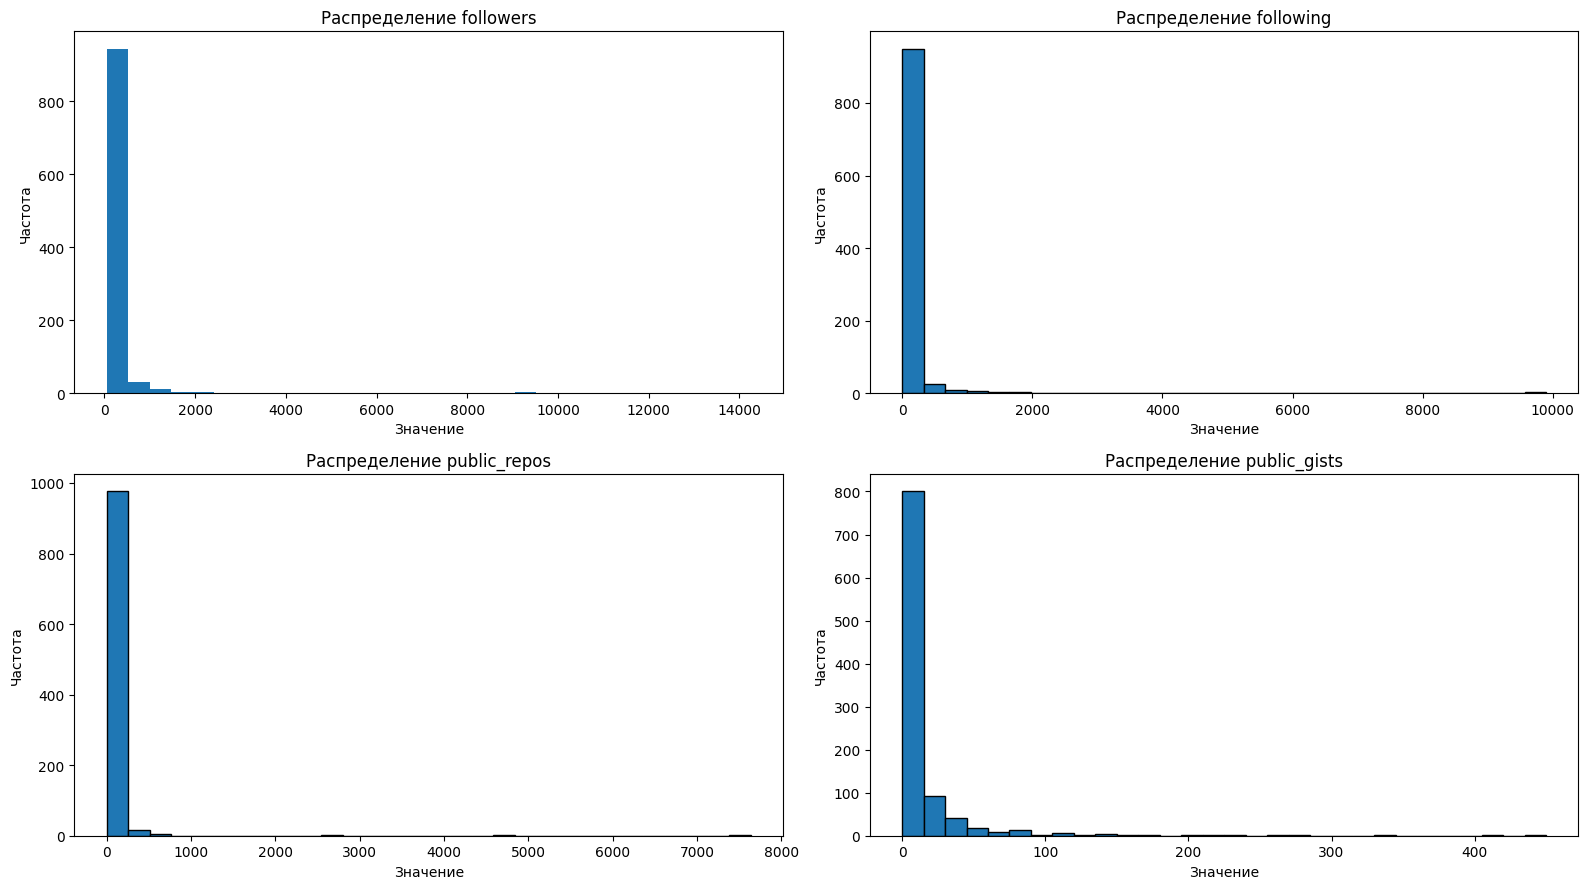

In [80]:
plt.figure(figsize=(16, 9))

plt.subplot(2, 2, 1)
plt.hist(users["followers"].dropna(), bins=30)
plt.title("Распределение followers")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.subplot(2, 2, 2)
plt.hist(users["following"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение following")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.subplot(2, 2, 3)
plt.hist(users["public_repos"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение public_repos")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.subplot(2, 2, 4)
plt.hist(users["public_gists"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение public_gists")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

Из-за сильной правосторонней ассиметрии данные читаются не очень хорошо - почти все наблюдения визуально сжимаются возле 0. Поэтому применим логарифмическое преобразование

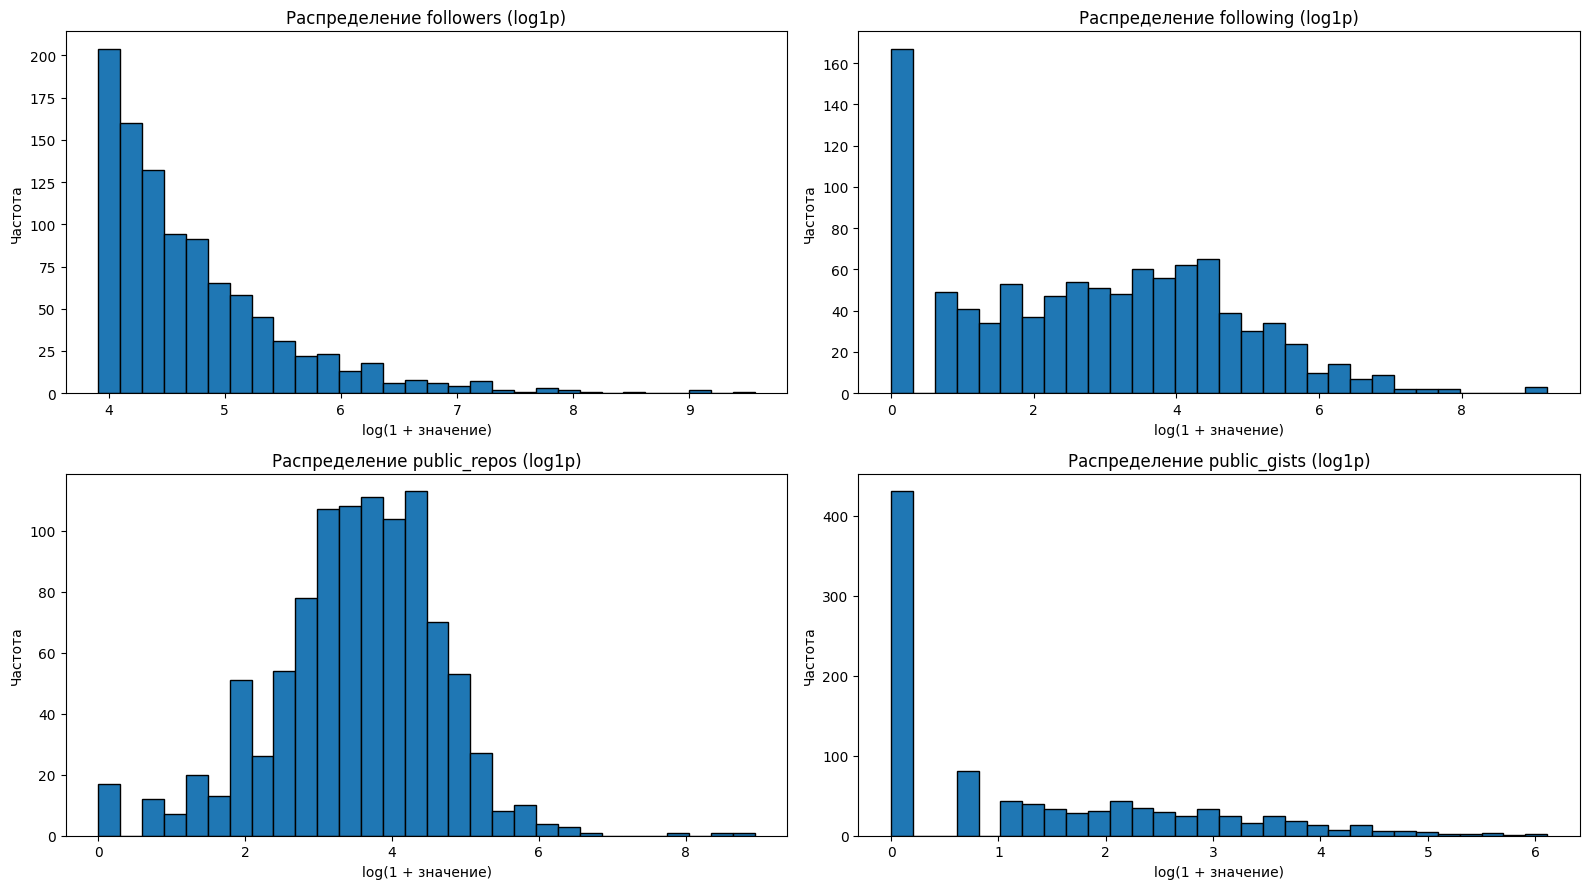

In [81]:
plt.figure(figsize=(16, 9))

plt.subplot(2, 2, 1)
plt.hist(np.log1p(users["followers"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение followers (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.subplot(2, 2, 2)
plt.hist(np.log1p(users["following"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение following (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.subplot(2, 2, 3)
plt.hist(np.log1p(users["public_repos"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение public_repos (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.subplot(2, 2, 4)
plt.hist(np.log1p(users["public_gists"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение public_gists (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

### Выводы

По распределению followers видим, что у большинства пользователей подписчиков немного, а аккаунты с очень большим числом подписчиков встречаются редко. Распределение всё равно остаётся скошенным вправо

Что касаемо following - есть заметная группа пользователей с очень маленьким числом подписок, но в целом признак распределён более широко, чем followers. То есть подписываться на другие аккаунты пользователи могут довольно активно

У public_repos основная часть пользователей имеет небольшое или среднее число публичных репозиториев. Очень больших значений мало

По распределению public_gists видим, что у большинства пользователей публичных фрагментов кода либо нет совсем, либо их очень мало. Этот признак самый сильно смещённый к нулю

По всем четырём признакам понятно, что основная масса пользователей имеет сравнительно небольшие значения, а очень большие значения встречаются только у небольшой части аккаунтов




## 6. Univariate analysis для репозиториев

Построим базовые гистограммы по основным числовым признакам репозиториев

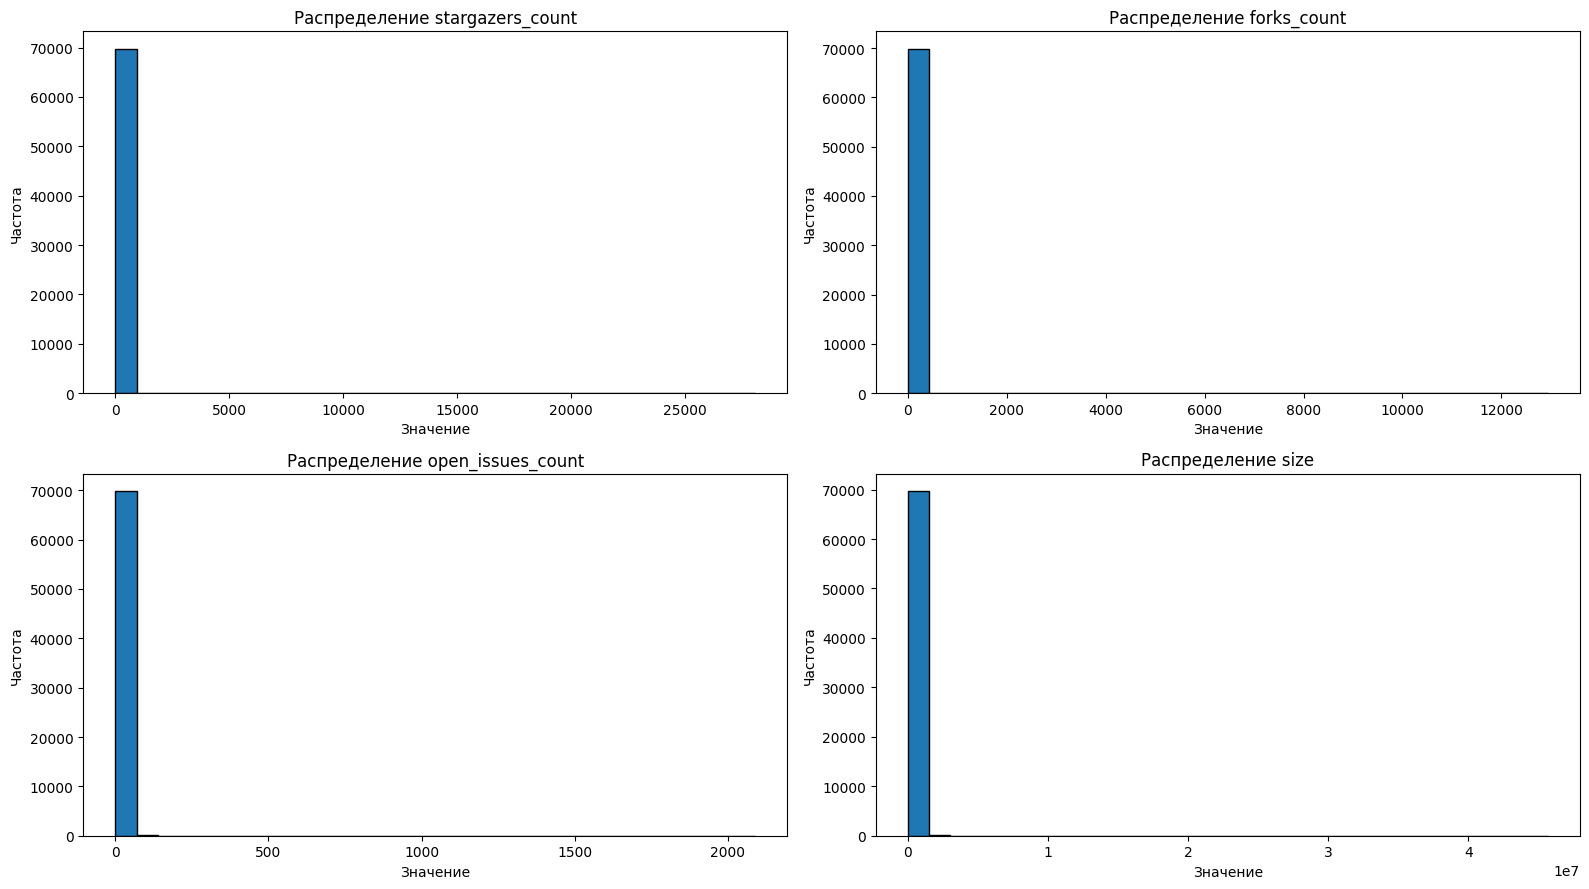

In [82]:
plt.figure(figsize=(16, 9))

plt.subplot(2, 2, 1)
plt.hist(repos["stargazers_count"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение stargazers_count")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.subplot(2, 2, 2)
plt.hist(repos["forks_count"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение forks_count")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.subplot(2, 2, 3)
plt.hist(repos["open_issues_count"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение open_issues_count")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.subplot(2, 2, 4)
plt.hist(repos["size"].dropna(), bins=30, edgecolor="black")
plt.title("Распределение size")
plt.xlabel("Значение")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

Аналогичная ситуация с нечитаемостью. Поступим также

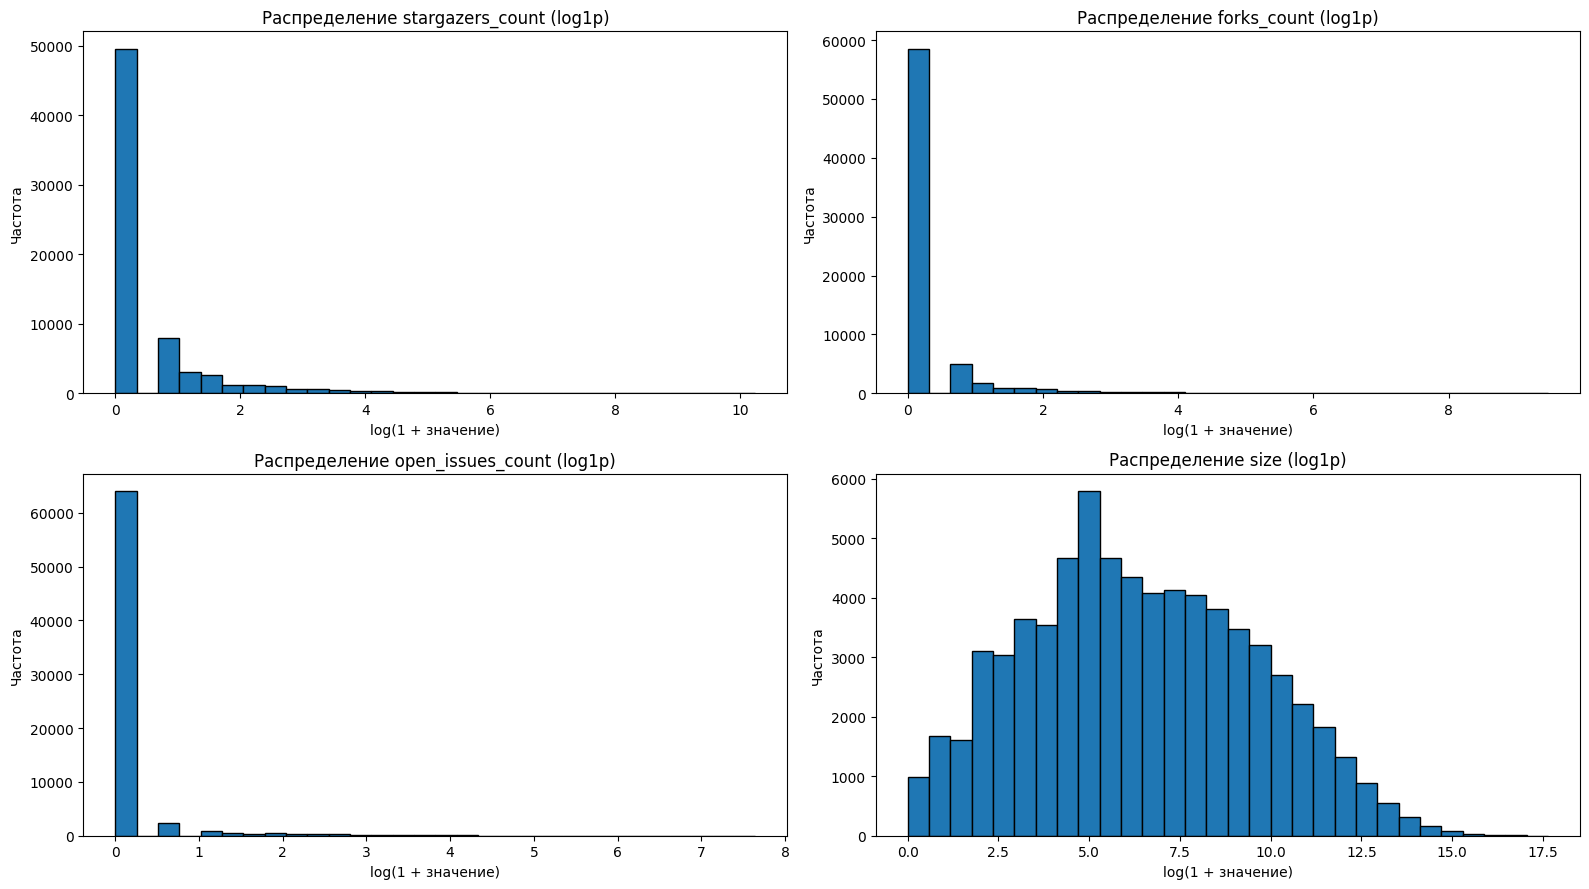

In [83]:
plt.figure(figsize=(16, 9))

plt.subplot(2, 2, 1)
plt.hist(np.log1p(repos["stargazers_count"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение stargazers_count (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.subplot(2, 2, 2)
plt.hist(np.log1p(repos["forks_count"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение forks_count (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.subplot(2, 2, 3)
plt.hist(np.log1p(repos["open_issues_count"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение open_issues_count (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.subplot(2, 2, 4)
plt.hist(np.log1p(repos["size"].dropna()), bins=30, edgecolor="black")
plt.title("Распределение size (log1p)")
plt.xlabel("log(1 + значение)")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

### Выводы

По распределению stargazers_count видим, что у большинства репозиториев звёзд или очень мало или вообще нет. Репозитории с большим числом звёзд встречаются редко

По поводу forks_count - картина похожая - у основной части репозиториев форков мало, а активно форкаемые проекты составляют небольшую долю

Из распределения open_issues_count видим, что у большинства репозиториев открытых задач/обсуждений или почти нет, или вообще нет. Большие значения встречаются редко, поэтому признак сильно сосредоточен около нуля

У size распределение размера выглядит уже более плавным. Основная часть репозиториев имеет небольшой или средний размер, а вот очень крупные репозитории встречаются заметно реже

По популярности и активности репозиториев выборка в основном состоит из небольших и не очень популярных проектов, а действительно крупные или заметные репозитории встречаются редко


## 7. Статистика по базовым категориальным признакам репозиториев

Теперь посмотрим на несколько категориальных признаков репозиториев и на основной язык из поля language

In [84]:
repos["fork"].value_counts()

,count
fork,
True,38801
False,31140


In [85]:
repos["archived"].value_counts()

,count
archived,
False,67320
True,2621


In [86]:
repos["owner_type"].value_counts()

,count
owner_type,
User,68288
Organization,1653


In [87]:
repos["visibility"].value_counts()

,count
visibility,
public,69941


### Выводы

В выборке форков немного больше, чем обычных репозиториев

Архивных репозиториев мало, основная часть репозиториев не архивирована

Почти все репозитории принадлежат пользователям, а не организациям

Все репозитории в выборке публичные

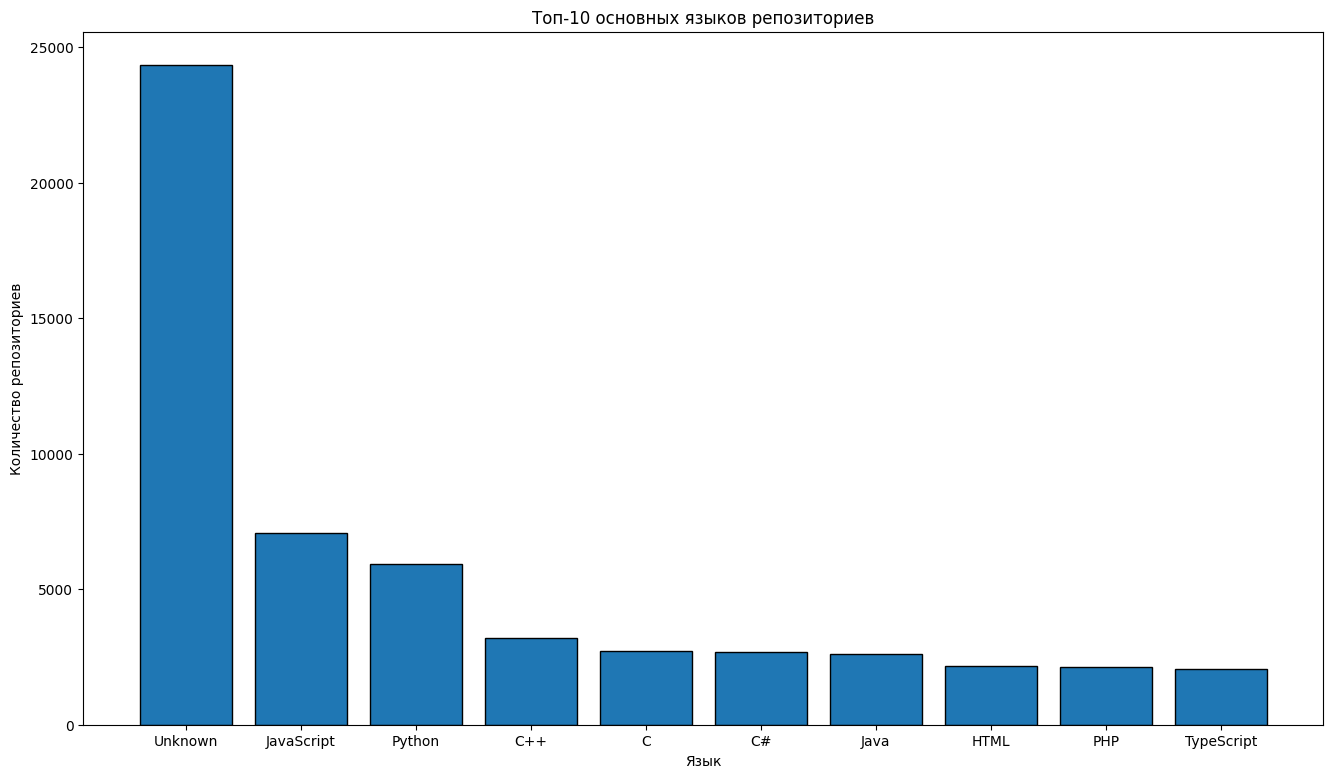

In [88]:
top_lang = repos["language"].fillna("Unknown").value_counts().head(10)

plt.figure(figsize=(16, 9))
plt.bar(top_lang.index, top_lang.values, edgecolor="black")
plt.title("Топ-10 основных языков репозиториев")
plt.xlabel("Язык")
plt.ylabel("Количество репозиториев")

plt.show()

### Выводы

По полю language очень много значений вида Unknown, а среди заполненных значений лидируют JavaScript, Python, C++

Тут важно напомнить, что это поле показывает именно основной язык репозитория

Чтобы понять реальные навыки пользователей и реальный языковой состав репозиториев, мы перейдем к lang_bytes и lang_pct

## 8. Анализ навыков по языкам через lang_bytes и lang_pct

Тут мы посмотрим не только на основной язык репозитория, но и на полный языковой состав проектов через lang_bytes и lang_pct, чтобы точнее понять, на каких языках реально пишут пользователи и какие навыки у них встречаются чаще всего. Чтобы убрать совсем малозначимые вклады, дальше будем отсекать нижние 5% по объему языка


In [89]:
def parse_jd(x):

    if pd.isna(x):
        return {}

    x = str(x).strip()

    if x == '':
        return {}

    try:
        return json.loads(x)

    except Exception:
        return {}

repos['lang_bytes_d'] = repos['lang_bytes'].apply(parse_jd)
repos['lang_pct_d'] = repos['lang_pct'].apply(parse_jd)

bytes_a = []

for d in repos['lang_bytes_d']:
    for byte_c in d.values():
        bytes_a.append(byte_c)

th = np.percentile(bytes_a, 5)


In [90]:
rows = []

for i in repos.index:
    user = repos.at[i, 'sample_user_login']
    repo_id = repos.at[i, 'id']
    lang_bytes_d = repos.at[i, 'lang_bytes_d']
    lang_pct_d = repos.at[i, 'lang_pct_d']

    for lang, byte_c in lang_bytes_d.items():
        if byte_c > th:
            rows.append([user, repo_id, lang, byte_c, lang_pct_d.get(lang, np.nan)])

skills = pd.DataFrame(rows, columns=['sample_user_login', 'repo_id', 'language', 'bytes', 'pct'])

print('Размер таблицы skills:', skills.shape)
skills.head()

Размер таблицы skills: (183811, 5)


,sample_user_login,repo_id,language,bytes,pct
0,Kwynto,515339264,Go,14480,100.000000
1,Kwynto,471783700,Go,26344,100.000000
2,Kwynto,773330026,Go,29231,99.074702
3,Kwynto,773330026,Shell,273,0.925298
4,Kwynto,674351858,Go,154687,62.459420


In [91]:
lang_stats = skills.groupby('language').agg(user_c =('sample_user_login', 'nunique'), repo_c=('repo_id', 'nunique'), bytes_t =('bytes', 'sum')).sort_values('user_c', ascending=False)

lang_stats.head(15)


,user_c,repo_c,bytes_t
language,,,
HTML,864,15742,11099287573
JavaScript,853,18483,7283953482
Shell,828,13540,1287911332
CSS,806,11484,876440617
Python,771,15051,10746356377
Makefile,663,7893,1225844905
C,655,9373,164668749058
C++,653,9004,29806112318
Dockerfile,642,4645,21865540


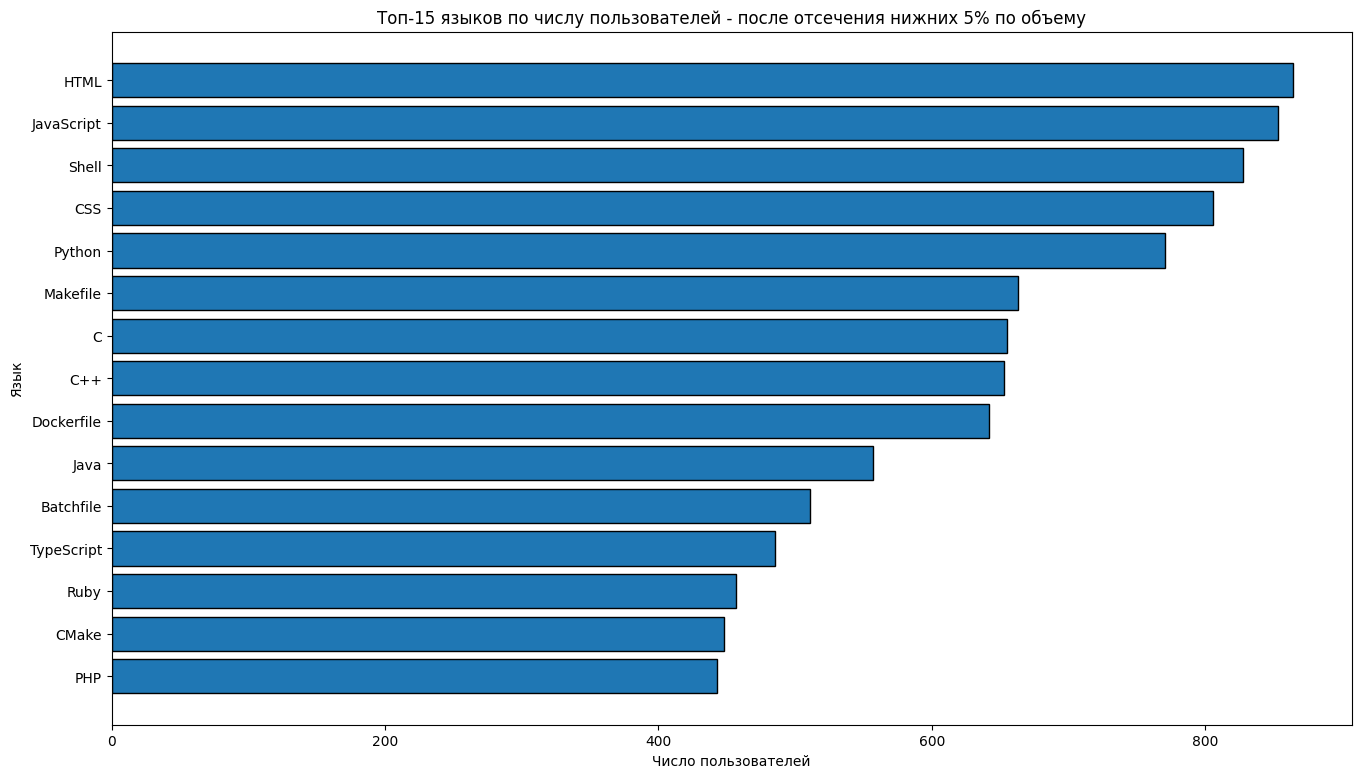

In [92]:
top15 = lang_stats["user_c"].head(15)

plt.figure(figsize=(16, 9))
plt.barh(top15.index[::-1], top15.values[::-1], edgecolor="black")
plt.xlabel("Число пользователей")
plt.ylabel("Язык")
plt.title("Топ-15 языков по числу пользователей - после отсечения нижних 5% по объему")

plt.show()

### Вывод

Если смотреть не на одно поле language, а на реальные языки в репозиториях после отсечения нижних 5% по объему, то картина становится богаче. По числу пользователей в топе оказываются HTML, JavaScript, Shell, CSS, Python и др. Здесь видно более реалистичную картину навыков, потому что, например, один репозиторий может быть многоязычным, у пользователя может быть несколько разных репозиториев и тут сильнее начинают нормально проявляться некоторые вспомогательные языки по типу HTML

## 9. Распределение числа репозиториев на пользователя

Тут мы посмотрим, как распределено число репозиториев на одного пользователя, чтобы понять, у скольких пользователей в выборке репозиториев немного, а у скольких их заметно больше

In [93]:
rep_by_user = repos.groupby("sample_user_login").size()
rep_by_user.describe()

,0
count,983.000000
mean,71.150560
std,303.007074
min,1.000000
25%,18.000000
50%,36.000000
75%,71.500000
max,7635.000000


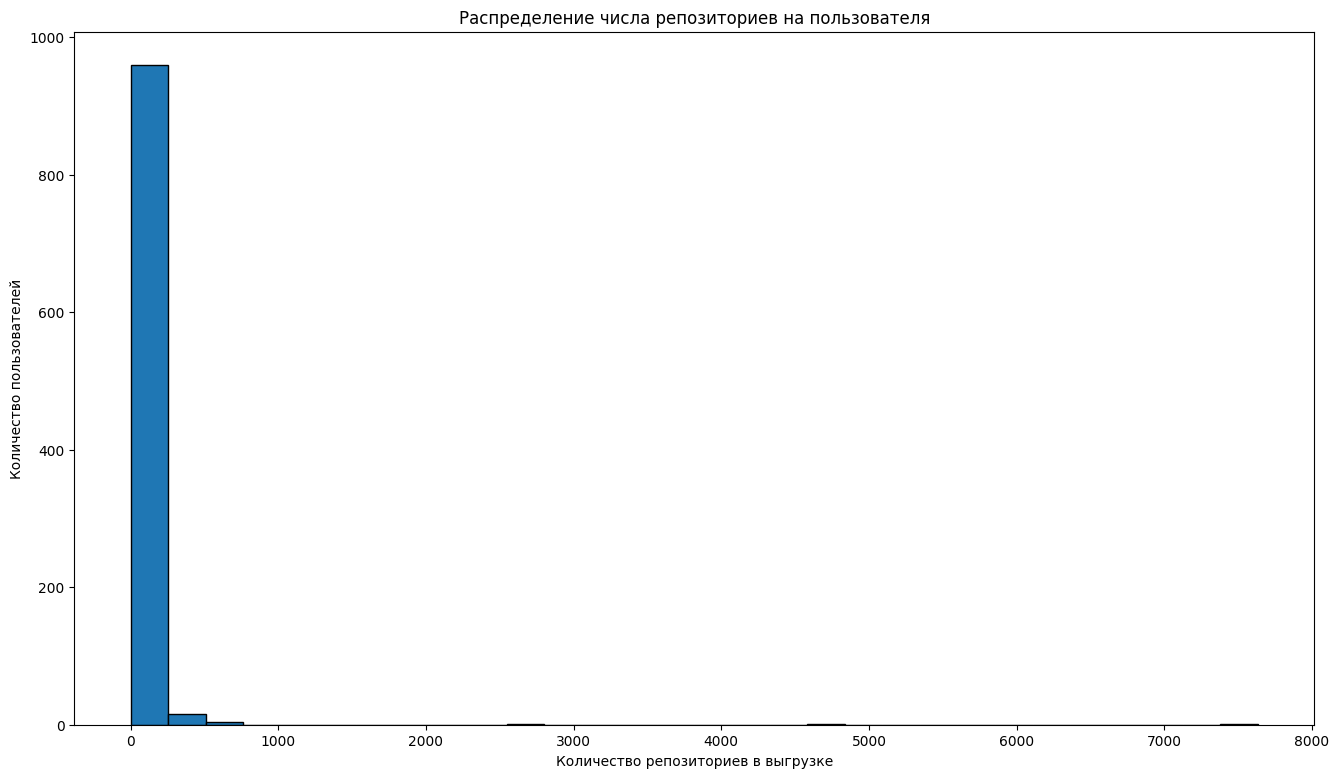

In [94]:
plt.figure(figsize=(16, 9))
plt.hist(rep_by_user, bins = 30, edgecolor = "black")
plt.title("Распределение числа репозиториев на пользователя")
plt.xlabel("Количество репозиториев в выгрузке")
plt.ylabel("Количество пользователей")

plt.show()

Тут снова сталкиваемся с проблемой того, что график плохо читается из-за сильной правосторонней асимметрии. Применим логарифмическое преобразование

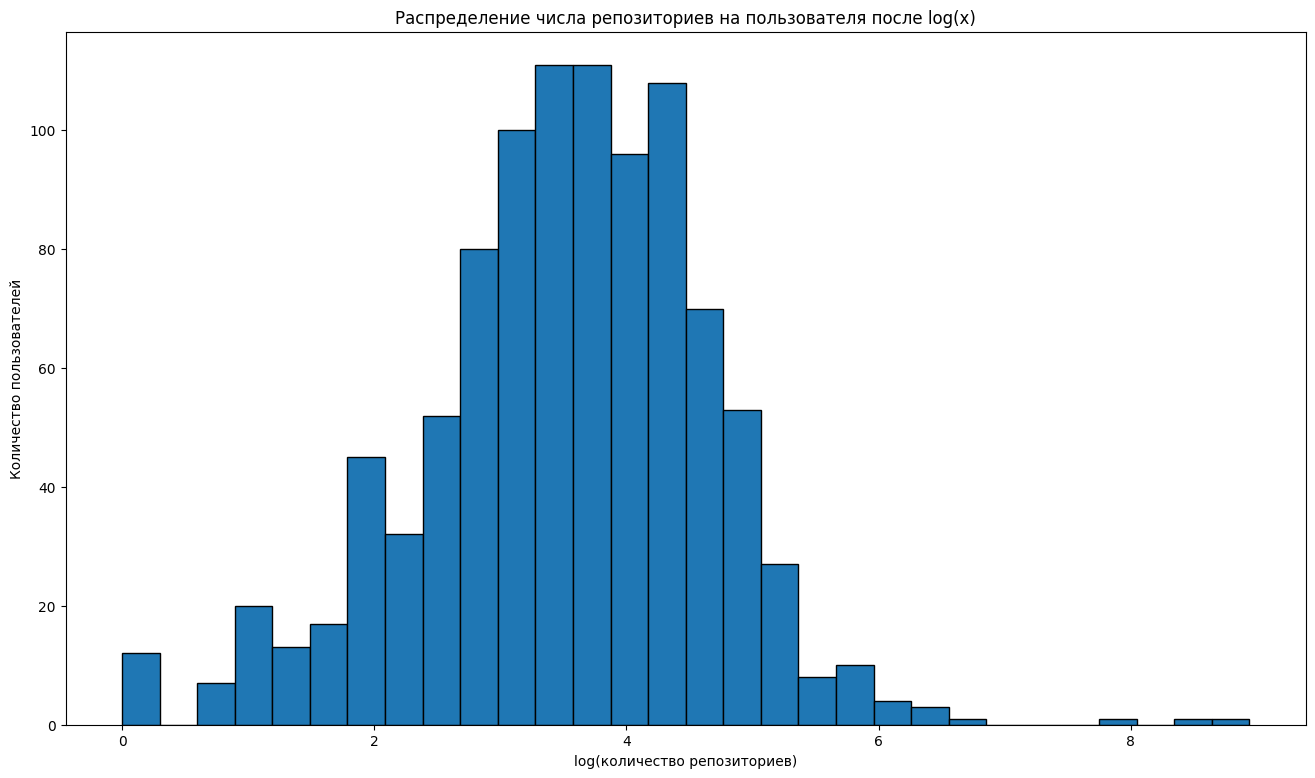

In [95]:
plt.figure(figsize=(16, 9))
plt.hist(np.log(rep_by_user), bins=30, edgecolor="black")
plt.title("Распределение числа репозиториев на пользователя после log(x)")
plt.xlabel("log(количество репозиториев)")
plt.ylabel("Количество пользователей")

plt.show()

### Вывод

Тут видно, что у большинства пользователей число репозиториев находится в сравнительно небольшом или среднем диапазоне, а пользователей с очень большим количеством репозиториев в выборке мало

## 10. Распределение объёма языка и его доли в репозиториях

Теперь посмотрим отдельно на распределение объёма языка и на распределение его доли в репозиториях, чтобы понять, какие языки чаще выступают как основные, а какие как вспомогательные

Сначала посмотрим на распределение количества байт языка в репозиториях. Так как значения могут очень сильно отличаться, то для более удобного сравнения применим логарифмическое преобразование

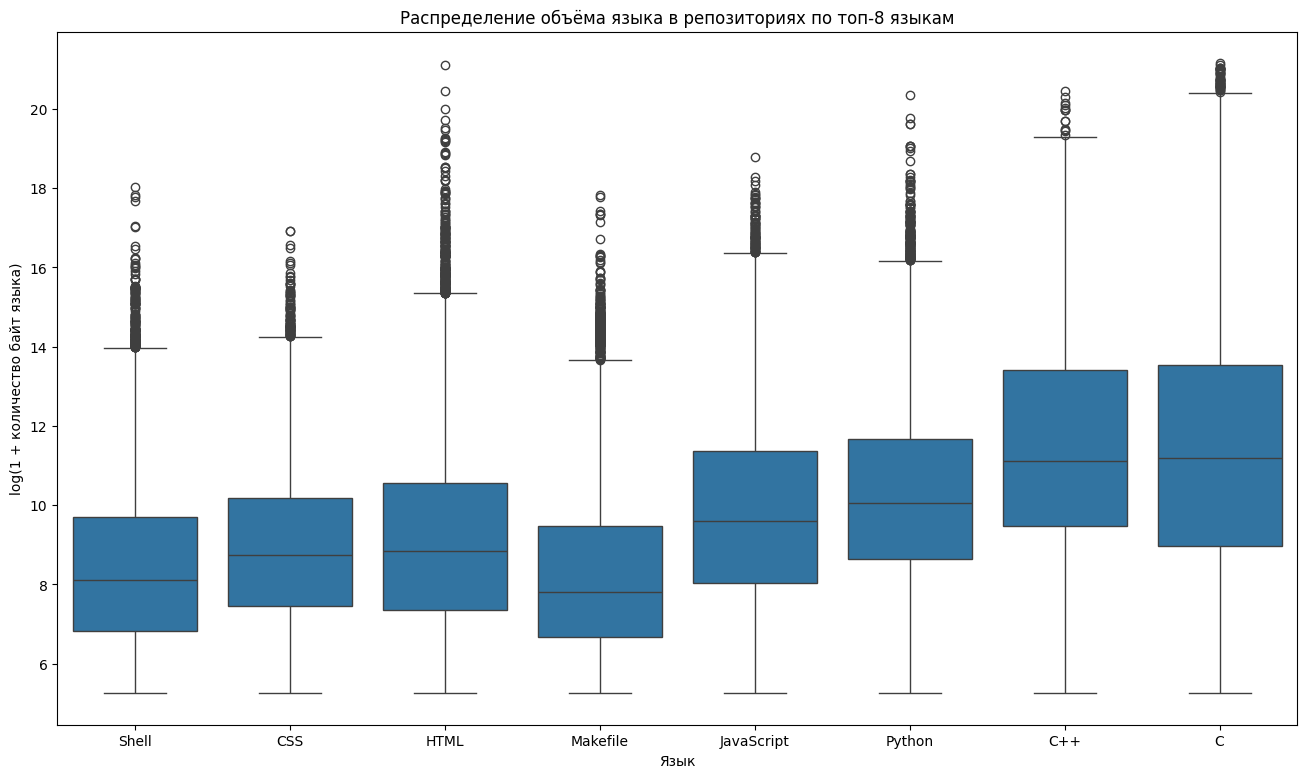

In [96]:
top_lang = lang_stats["repo_c"].head(8).index

box_data = skills[skills["language"].isin(top_lang)].copy()
box_data["log_bytes"] = np.log1p(box_data["bytes"])

plt.figure(figsize=(16, 9))
sns.boxplot(x="language", y="log_bytes", data=box_data)
plt.title("Распределение объёма языка в репозиториях по топ-8 языкам")
plt.xlabel("Язык")
plt.ylabel("log(1 + количество байт языка)")

plt.show()


### Вывод

По boxplot видим, что объём языков в репозиториях распределён довольно неравномерно: у всех языков есть и относительно небольшие значения, и крупные выбросы. При этом C, C++, Python и JavaScript в среднем выглядят более тяжёлыми по объёму, а Shell, CSS и Makefile чаще встречаются с более маленьким количеством байт



Теперь отдельно посмотрим на долю языка в репозиториях. Тут уже удобно использовать violinplot, потому что он позволяет лучше увидеть, где значения встречаются чаще, а где реже

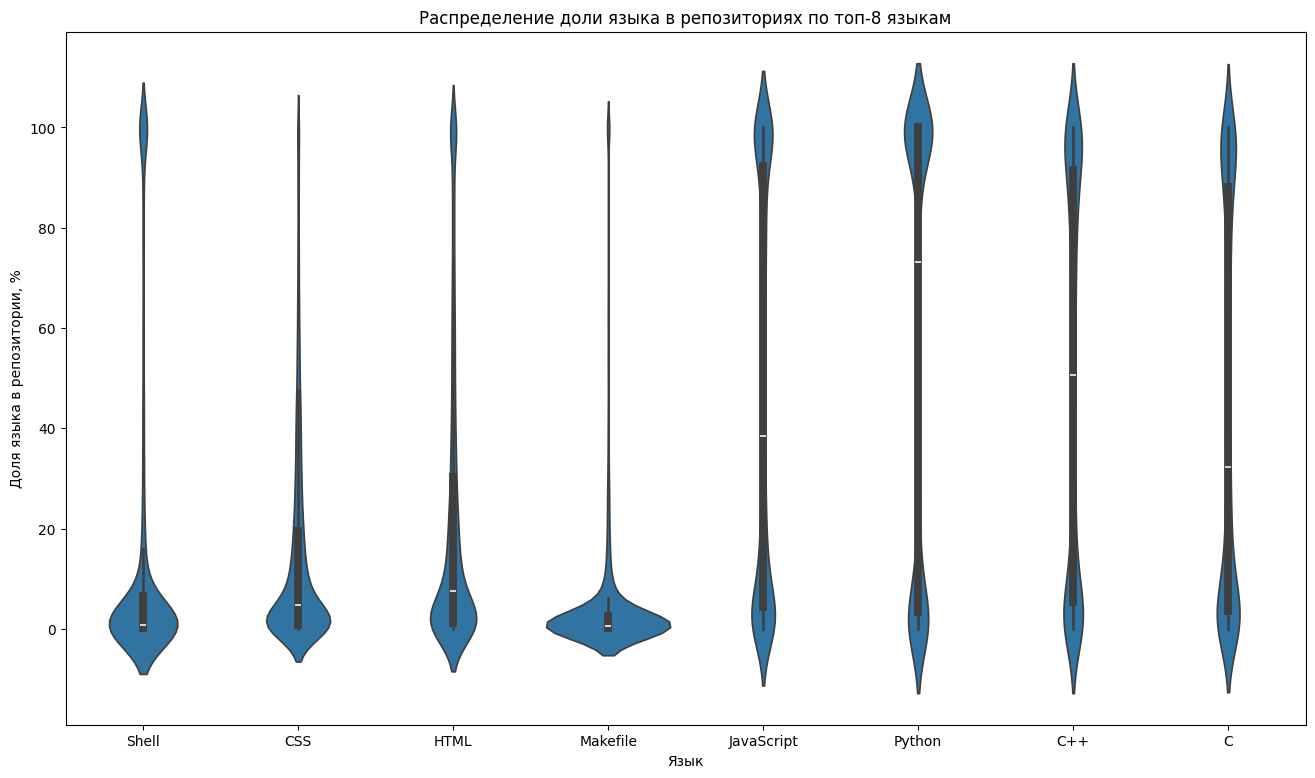

In [97]:
violin_data = skills[skills["language"].isin(top_lang)]

plt.figure(figsize=(16, 9))
sns.violinplot(x="language", y="pct", data=violin_data)
plt.title("Распределение доли языка в репозиториях по топ-8 языкам")
plt.xlabel("Язык")
plt.ylabel("Доля языка в репозитории, %")

plt.show()


### Вывод

По violinplot видим, что доля языка в репозиториях часто скапливается либо ближе к небольшим значениям, либо ближе к большим. Это еще раз показывает, что часть языков, например Shell, CSS и Makefile, чаще играет вспомогательную роль, а Python, C, C++ и JavaScript заметно чаще бывают одними из основных

## 11. Взаимная встречаемость языков в одном репозитории

Тут мы посмотрим, какие языки чаще всего встречаются вместе в одном репозитории. Так мы поймем, какими связками языки обычно используются на практике, и увидим более устойчивые сочетания технологий

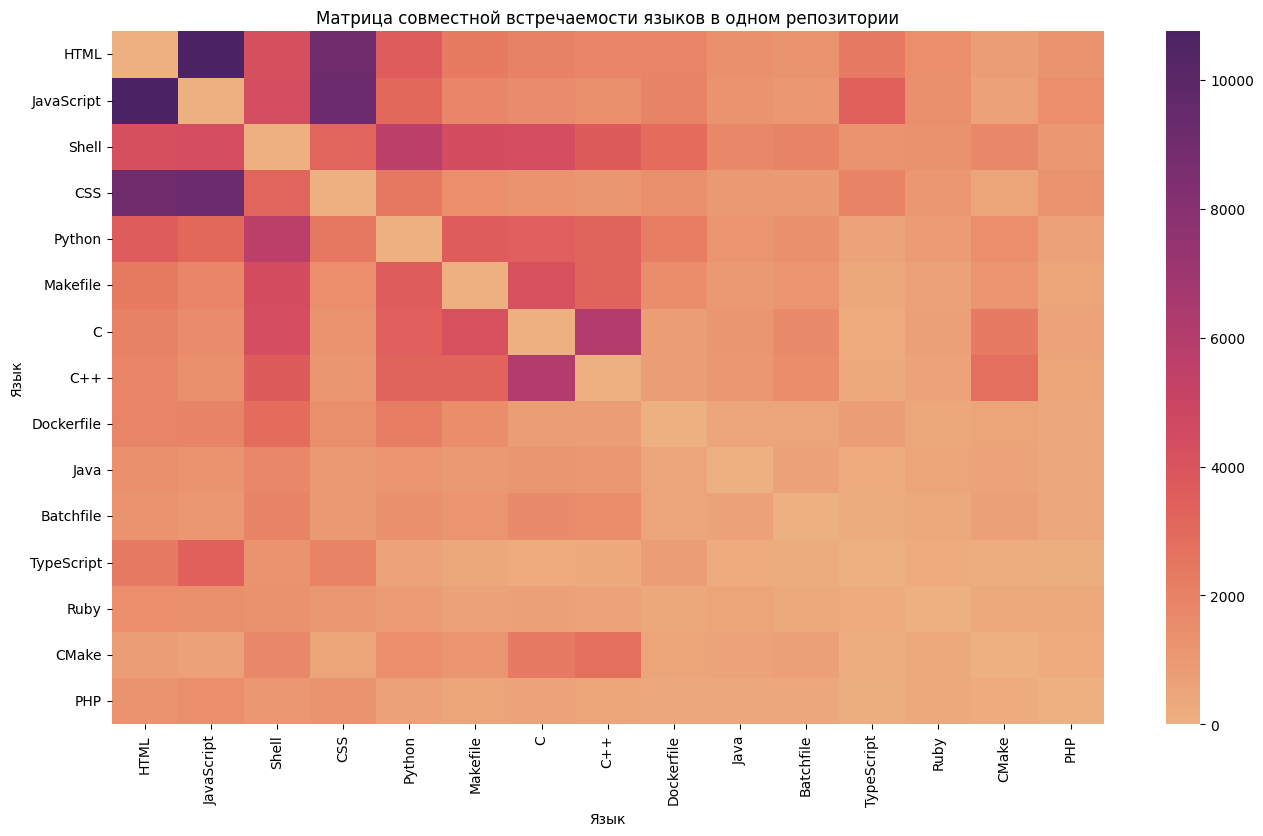

In [98]:
top_langs = lang_stats["repo_c"].head(15).index

repo_lang = skills[skills["language"].isin(top_langs)].groupby("repo_id")["language"].agg(list)

hmap_arr = np.array([[0 for i in range(len(top_langs))] for j in range(len(top_langs))])
idx_map = {val: key for key, val in enumerate(top_langs)}

for item in repo_lang:
    item = list(set(item))
    for i in range(len(item)):
        for j in range(i+1, len(item)):
            if item[i] in idx_map.keys() and item[j] in idx_map.keys():
                hmap_arr[idx_map[item[i]]][idx_map[item[j]]] += 1
                hmap_arr[idx_map[item[j]]][idx_map[item[i]]] += 1

plt.figure(figsize=(16, 9))
sns.heatmap(pd.DataFrame(hmap_arr, index=idx_map.keys(), columns=idx_map.keys()), cmap="flare")
plt.title("Матрица совместной встречаемости языков в одном репозитории")
plt.xlabel("Язык")
plt.ylabel("Язык")

plt.show()


### Вывод

По тепловой карте видно, что чаще всего вместе встречаются связки HTML, JavaScript и CSS, что в целом ожидаемо для веб-разработки. Также хорошо заметны сочетания C и C++, Python и Shell, Shell и Makefile, то есть кроме веб-разработки здесь выделяются связки языков, которые чаще связаны с более системными задачами